<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Event_Studies_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [54]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [55]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [56]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-2003-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2003_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2003_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2003_datos_eng_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2003_datos_esp_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2011-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2011_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_eng.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_esp.dta  
Archive:  latinobarometro/latinobarometro-1996-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_1996_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1996_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1996_datos_esp_v2014_06_27.dta  
  inflating: latinobar

In [57]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
},

# ---------------------------------
# Confianza en el Congreso
# ---------------------------------

"confianza_congreso": {
    1995: "p27i",
    1996: "p33i",
    1997: "sp63f",
    1998: "sp38f",
    2000: "P35ST_F",
    2001: "p61stf",
    2002: "p36std",
    2003: "p21stf",
    2004: "p34stf",
    2005: "p45sta",
    2006: "p24st_f",
    2007: "p24st_f",
    2008: "p28st_a",
    2009: "p26st_a",
    2010: "P20ST_A",
    2011: "P22ST_A",
    2013: "P26TGB_C",
    2015: "P16ST_F",
    2016: "P13STD",
    2017: "P14ST_D",
    2018: "P15STGBSC.D",
    2020: "p13st_d",
    2023: "P13ST_D",
    2024: "P14ST.D"
},

# ---------------------------------
# Confianza en el Gobierno
# ---------------------------------

"confianza_gobierno": {
    1995: "p27m",
    1996: "p33m",
    2002: "p34std",
    2003: "p23stg",
    2004: "p32std",
    2005: "p45stc",
    2006: "p32st_a",
    2007: "p24st_a",
    2008: "p31s_ta",
    2009: "p24st_a",
    2010: "P18ST_A",
    2011: "P20ST_A",
    2013: "P26TGB_B",
    2015: "P16ST_G",
    2016: "P13STE",
    2017: "P14ST_E",
    2018: "P15STGBSC.E",
    2020: "p13st_e",
    2023: "P13ST_E",
    2024: "P14ST.E"
},

# ---------------------------------
# Confianza en el Poder Judicial
# ---------------------------------

"confianza_judicial": {
    1995: "p27d",
    1996: "p33d",
    1997: "sp63c",
    1998: "sp38c",
    2000: "P35ST_C",
    2001: "p61stc",
    2002: "p34stc",
    2003: "p21ste",
    2004: "p34stb",
    2005: "p42std",
    2006: "p24st_a",
    2007: "p24st_d",
    2008: "p28st_b",
    2009: "p26st_b",
    2010: "P20ST_B",
    2011: "P22ST_B",
    2013: "P26TGB_E",
    2015: "P16ST_H",
    2016: "P13STF",
    2017: "P14ST_F",
    2018: "P15STGBSC.F",
    2020: "p13st_f",
    2023: "P13ST_F",
    2024: "P14ST.F"
},

# ---------------------------------
# Día
# ---------------------------------

"dia_real": {
    1997: "diareal",
    1998: "diareal",
    2000: "diareal",
    2001: "diareal",
    2002: "diareal",
    2003: "diareal",
    2004: "diareal",
    2005: "diareal",
    2006: "diareal",
    2007: "diareal",
    2008: "diareal",
    2009: "diareal",
    2010: "diareal",
    2011: "diareal",
    2013: "diareal",
    2015: "diareal",
    2016: "diareal",
    2017: "diareal",
    2018: "DIAREAL",
    2020: "diareal",
    2023: "diareal",
    2024: "DIAREAL",
},


# ---------------------------------
# Mes
# ---------------------------------

"mes_real": {
    1997: "mesreal",
    1998: "mesreal",
    2000: "mesreal",
    2001: "mesreal",
    2002: "mesreal",
    2003: "mesreal",
    2004: "mesreal",
    2005: "mesreal",
    2006: "mesreal",
    2007: "mesreal",
    2008: "mesreal",
    2009: "mesreal",
    2010: "mesreal",
    2011: "mesreal",
    2013: "mesreal",
    2015: "mesreal",
    2016: "mesreal",
    2017: "mesreal",
    2018: "MESREAL",
    2020: "mesreal",
    2023: "mesreal",
    2024: "MESREAL",
}


}

In [58]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [59]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "dia_real",
            "mes_real",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote",
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [60]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


conversion_confianza = {
    4: 1,  # ninguna
    3: 2,  # poca
    2: 3,  # algo
    1: 4   # mucha confianza
}

master["confianza_congreso"] = (
    master["confianza_congreso"]
    .map(conversion_confianza)
)

master["confianza_gobierno"] = (
    master["confianza_gobierno"]
    .map(conversion_confianza)
)

master["confianza_judicial"] = (
    master["confianza_judicial"]
    .map(conversion_confianza)
)

In [61]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

# Confianza institucional es el promedio de congreso, gobierno y judicial.
master["confianza_institucional"] = (
    master[
        [
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]
    ].mean(axis=1)
)

In [62]:
#Eliminamos España
master = master[master['country'] != 724]

In [63]:
vars_z = [
     "life_satisfaction",
     "interest_politics",
     "education" ,
     "econ_country",
     "confianza_institucional",
     "polarizacion_ind",
     "democracia_vdem"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

# Identificación

In [65]:
import pandas as pd

# Crear fecha completa de la encuesta
master['fecha_encuesta'] = pd.to_datetime(
    dict(
        year=pd.to_numeric(master['wave'], errors='coerce'),
        month=pd.to_numeric(master['mes_real'], errors='coerce'),
        day=pd.to_numeric(master['dia_real'], errors='coerce')
    ),
    errors='coerce'
)

# Fecha de inicio y fin de cada ola en cada país
fechas_encuestas = (
    master
    .groupby(['country', 'wave'], as_index=False)
    .agg(
        fecha_inicio=('fecha_encuesta', 'min'),
        fecha_fin=('fecha_encuesta', 'max'),
        n_obs=('fecha_encuesta', 'count')
    )
    .sort_values(['country', 'wave'])
)

In [66]:
# Levanta los datos de elecciones de acá https://www.electionguide.org/
ifes=pd.read_csv('IFES.csv', sep=';')

In [74]:
import pandas as pd

# ============================================================
# 1. Nombres de países
# ============================================================

country_names = {
    32: 'Argentina',
    68: 'Bolivia',
    76: 'Brazil',
    152: 'Chile',
    170: 'Colombia',
    188: 'Costa Rica',
    214: 'Dominican Republic',
    218: 'Ecuador',
    222: 'El Salvador',
    320: 'Guatemala',
    340: 'Honduras',
    484: 'Mexico',
    558: 'Nicaragua',
    591: 'Panama',
    600: 'Paraguay',
    604: 'Peru',
    858: 'Uruguay',
    862: 'Venezuela'
}

# ============================================================
# 2. Fecha de entrevista en MASTER
#    (si ya existe, esta parte se puede omitir)
# ============================================================

master['fecha_encuesta'] = pd.to_datetime(
    dict(
        year=pd.to_numeric(master['wave'], errors='coerce'),
        month=pd.to_numeric(master['mes_real'], errors='coerce'),
        day=pd.to_numeric(master['dia_real'], errors='coerce')
    ),
    errors='coerce'
)

# ============================================================
# 3. Nombre del país en MASTER
# ============================================================

master['country_name'] = master['country'].map(country_names)

# ============================================================
# 4. Ventana de cada ola × país
# ============================================================

ventanas = (
    master
    .groupby(
        ['country', 'country_name', 'wave'],
        as_index=False
    )
    .agg(
        fecha_inicio=('fecha_encuesta', 'min'),
        fecha_fin=('fecha_encuesta', 'max'),
        n_obs=('fecha_encuesta', 'count')
    )
)

# ============================================================
# 5. Limpiar fechas de IFES
# ============================================================

ifes['election_date'] = pd.to_datetime(
    ifes['Start Date']
    .astype(str)
    .str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
    errors='coerce'
)

# ============================================================
# 6. Identificar elecciones presidenciales y legislativas
# ============================================================

ifes['election_type'] = pd.NA

ifes.loc[
    ifes['Election for'].str.contains(
        'Presidency|President',
        case=False,
        na=False
    ),
    'election_type'
] = 'presidential'

ifes.loc[
    ifes['Election for'].str.contains(
        'Chamber|Senate|Congress|Assembly|Parliament|Legislative|Presidency|Referendum',
        case=False,
        na=False
    ),
    'election_type'
] = 'legislative'

# Nos quedamos solamente con las elecciones relevantes
elecciones = ifes[
    ifes['election_type'].notna() &
    ifes['election_date'].notna()
].copy()

# ============================================================
# 7. Cruzar países/olas con elecciones
# ============================================================

cruce = ventanas.merge(
    elecciones[
        [
            'Country',
            'Election for',
            'election_date',
            'election_type'
        ]
    ],
    left_on='country_name',
    right_on='Country',
    how='left'
)

# ============================================================
# 8. Seleccionar elecciones ocurridas dentro de la ventana
# ============================================================

elecciones_en_ola = cruce[
    cruce['election_date'].between(
        cruce['fecha_inicio'],
        cruce['fecha_fin']
    )
].copy()

# ============================================================
# 9. Consolidar elecciones que tienen varios registros en IFES
#    (ej.: presidencial + Senado + Diputados el mismo día)
# ============================================================

elecciones_en_ola = (
    elecciones_en_ola
    .groupby(
        [
            'country',
            'country_name',
            'wave',
            'fecha_inicio',
            'fecha_fin',
            'n_obs',
            'election_date'
        ],
        as_index=False
    )
    .agg(
        election_types=(
            'election_type',
            lambda x: ', '.join(sorted(set(x)))
        ),
        elections=(
            'Election for',
            lambda x: ' | '.join(x)
        )
    )
    .sort_values(
        ['country', 'wave', 'election_date']
    )
)

# ============================================================
# 10. Mostrar resultado
# ============================================================

elecciones_en_ola

,country,country_name,wave,fecha_inicio,fecha_fin,n_obs,election_date,election_types,elections
0,76,Brazil,2006,2006-10-10,2006-10-29,1204,2006-10-29,legislative,Brazilian Presidency
1,170,Colombia,2018,2018-06-06,2018-08-26,1200,2018-06-17,legislative,Colombian Presidency
2,218,Ecuador,2006,2006-10-07,2006-10-22,1200,2006-10-15,legislative,Ecuadorian National Assembly | Ecuadorian Pres...
3,218,Ecuador,2008,2008-09-02,2008-10-05,1200,2008-09-28,legislative,Referendum | Referendum
4,604,Peru,2016,2016-05-14,2016-06-13,1200,2016-06-05,legislative,Peruvian Presidency
5,862,Venezuela,2010,2010-09-04,2010-10-11,1200,2010-09-26,legislative,Venezuelan National Assembly
6,862,Venezuela,2020,2020-10-29,2020-12-15,1200,2020-12-06,legislative,Venezuelan National Assembly


#Event Study

In [75]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ============================================================
# VARIABLES
# ============================================================

variables = [
    'life_satisfaction',
    'interest_politics',
    'econ_country',
    'trust_people',
    'left_right_distance',
    'confianza_institucional'
]

# ============================================================
# PARÁMETROS DEL EVENT STUDY
# ============================================================

DIA_MIN = -15
DIA_MAX = 8
DIA_REFERENCIA = -1

# ============================================================
# COPIA DE MASTER Y FECHA DE ENTREVISTA
# ============================================================

master_es = master.copy()

master_es['fecha_entrevista'] = pd.to_datetime(
    dict(
        year=pd.to_numeric(master_es['wave'], errors='coerce'),
        month=pd.to_numeric(master_es['mes_real'], errors='coerce'),
        day=pd.to_numeric(master_es['dia_real'], errors='coerce')
    ),
    errors='coerce'
)

# ============================================================
# FUNCIÓN EVENT STUDY
# ============================================================

def event_study(data, variable, fecha_evento):

    data = data.dropna(subset=[variable, 'fecha_entrevista']).copy()

    # Días respecto de la elección
    data['dias_evento'] = (
        data['fecha_entrevista'] - fecha_evento
    ).dt.days

    # Ventana temporal
    data = data[
        data['dias_evento'].between(DIA_MIN, DIA_MAX)
    ].copy()

    # Si no hay observaciones, devolver None
    if len(data) == 0:
        return None, None

    # ========================================================
    # DUMMIES DE DÍA
    # ========================================================

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 como categoría de referencia
    nombre_ref = f'dia_{DIA_REFERENCIA}'

    if nombre_ref in X.columns:
        X = X.drop(columns=nombre_ref)

    X = sm.add_constant(X)

    # ========================================================
    # OLS
    # ========================================================

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # ========================================================
    # RESULTADOS
    # ========================================================

    resultados = []

    for dia in range(DIA_MIN, DIA_MAX + 1):

        if dia == DIA_REFERENCIA:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

            else:

                # No hubo observaciones ese día
                resultados.append({
                    'dia': dia,
                    'beta': np.nan,
                    'se': np.nan
                })

    r = pd.DataFrame(resultados)

    r['ci_low'] = (
        r['beta'] - 1.96 * r['se']
    )

    r['ci_high'] = (
        r['beta'] + 1.96 * r['se']
    )

    r['variable'] = variable
    r['n'] = len(data)

    return modelo, r


# ============================================================
# RECORRER TODAS LAS ELECCIONES
# ============================================================

todos_resultados = []
todos_modelos = {}

for i, eleccion in elecciones_en_ola.iterrows():

    country = eleccion['country']
    country_name = eleccion['country_name']
    wave = eleccion['wave']
    fecha_evento = pd.Timestamp(eleccion['election_date'])

    # --------------------------------------------------------
    # Muestra correspondiente a país + ola
    # --------------------------------------------------------

    es = master_es[
        (master_es['country'] == country) &
        (master_es['wave'] == wave)
    ].copy()

    # --------------------------------------------------------
    # Event studies para cada variable
    # --------------------------------------------------------

    for variable in variables:

        modelo, resultados = event_study(
            es,
            variable,
            fecha_evento
        )

        if resultados is None:
            continue

        # Identificación del evento
        resultados['country'] = country
        resultados['country_name'] = country_name
        resultados['wave'] = wave
        resultados['fecha_evento'] = fecha_evento
        resultados['election_types'] = eleccion['election_types']
        resultados['elections'] = eleccion['elections']

        # Guardar
        todos_resultados.append(resultados)

        # Guardar también el modelo
        clave = (
            country,
            wave,
            fecha_evento.strftime('%Y-%m-%d'),
            variable
        )

        todos_modelos[clave] = modelo


# ============================================================
# UNIFICAR TODOS LOS RESULTADOS
# ============================================================

resultados_event_study = pd.concat(
    todos_resultados,
    ignore_index=True
)

# Orden
resultados_event_study = resultados_event_study[
    [
        'country',
        'country_name',
        'wave',
        'fecha_evento',
        'election_types',
        'elections',
        'variable',
        'dia',
        'beta',
        'se',
        'ci_low',
        'ci_high',
        'n'
    ]
].sort_values(
    [
        'country',
        'wave',
        'fecha_evento',
        'variable',
        'dia'
    ]
).reset_index(drop=True)

/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(
/tmp/ipykernel_695/2171789468.py:89: SingularMatrixWarning: The 

Observaciones en pooled: 2879
Eventos incluidos: 7


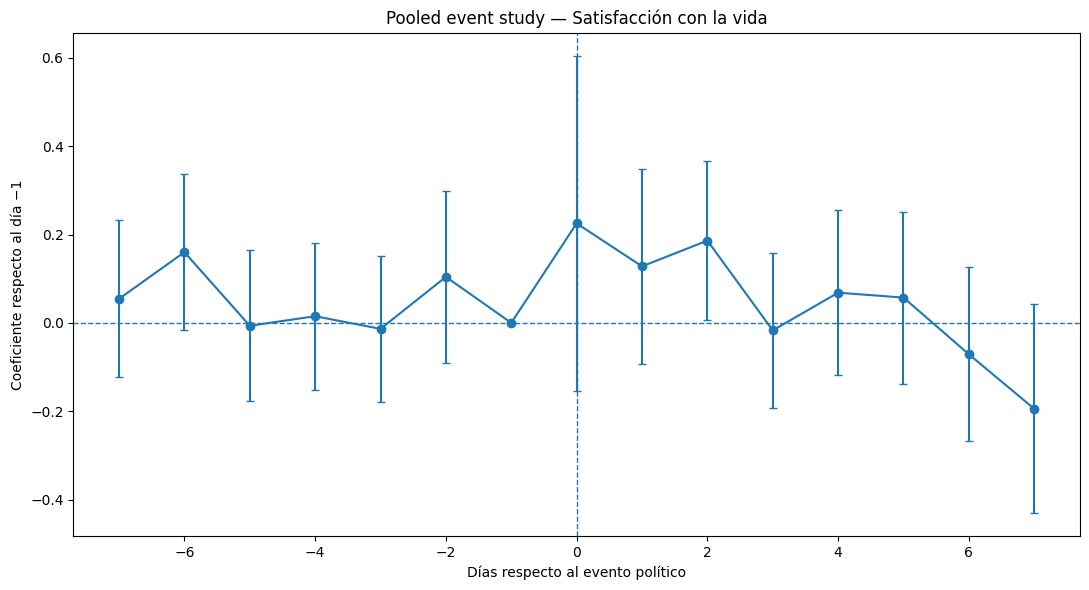

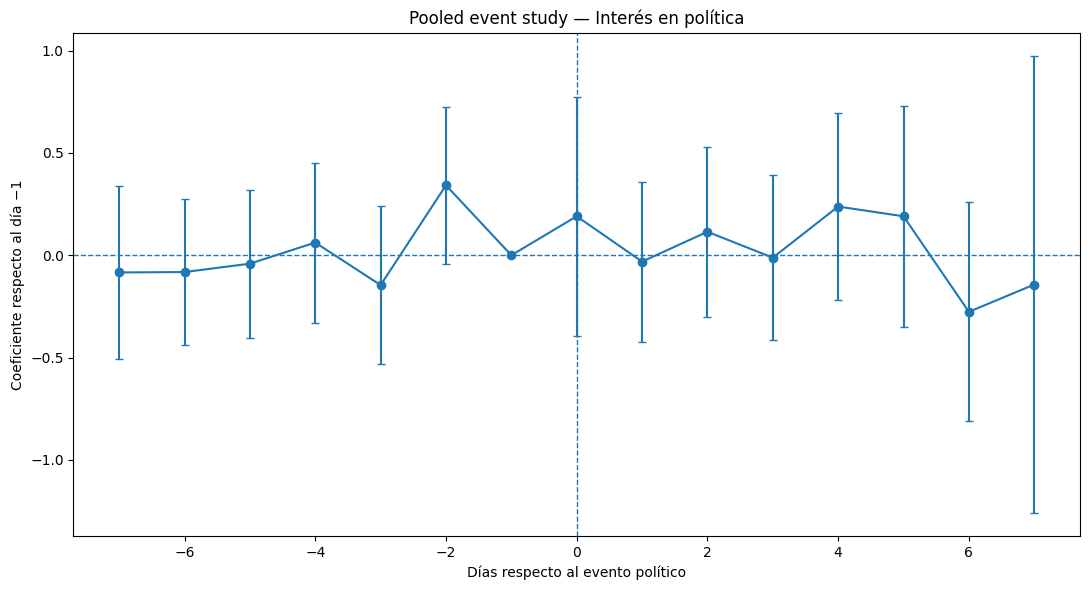

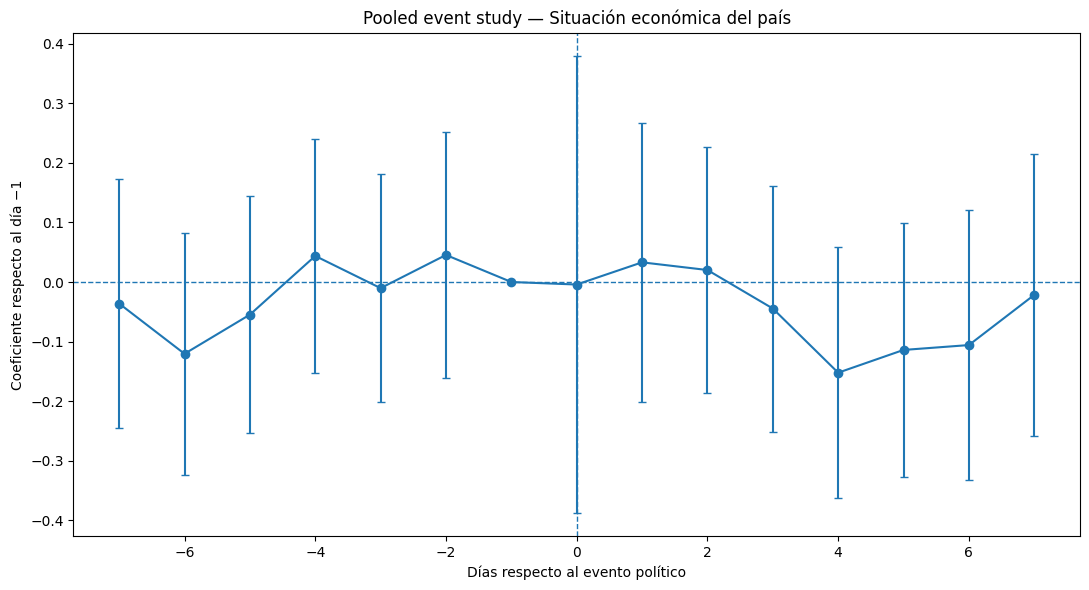

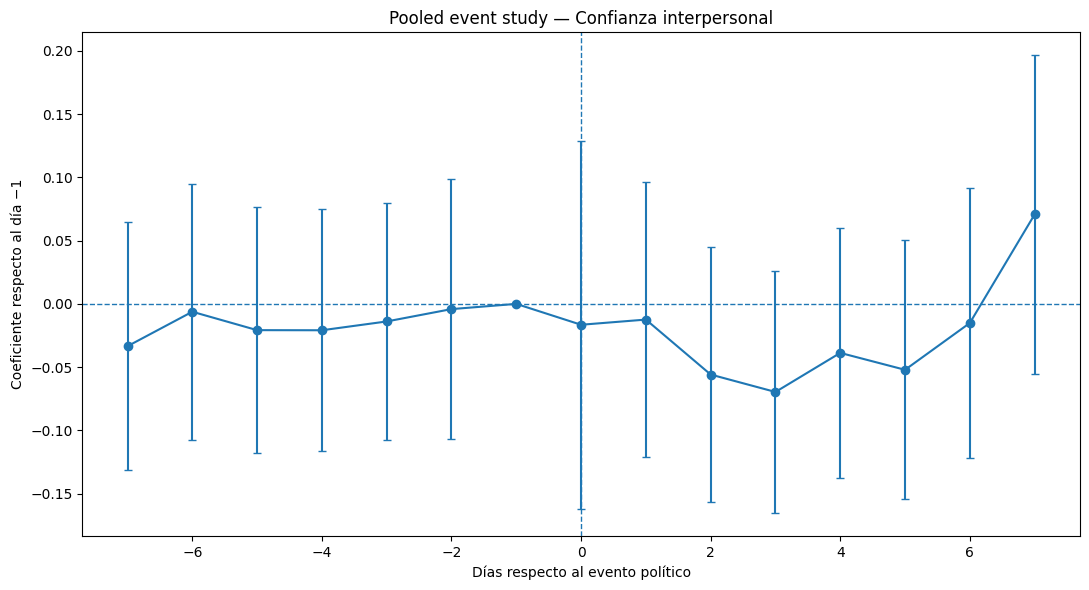

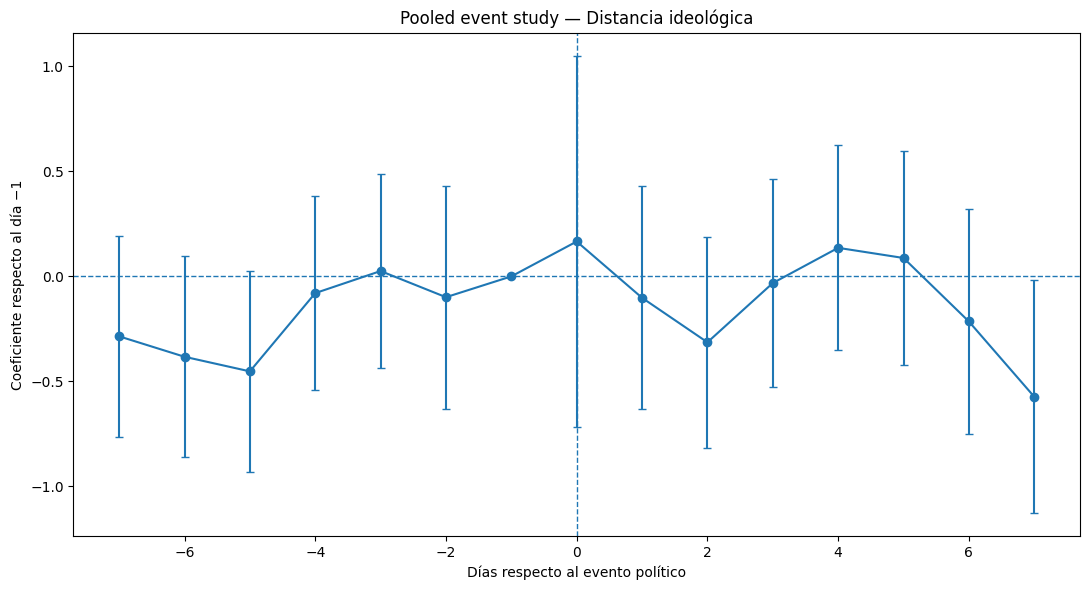

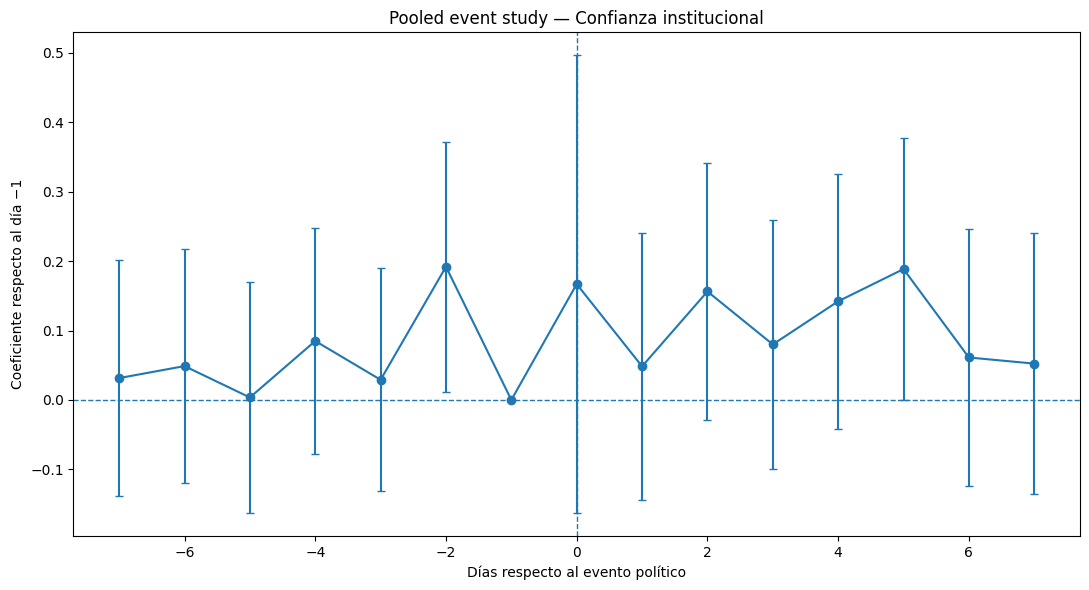

               variable  dia      beta       se    ci_low   ci_high
      life_satisfaction   -7  0.054403 0.090482 -0.122942  0.231747
      life_satisfaction   -6  0.160070 0.090067 -0.016462  0.336601
      life_satisfaction   -5 -0.006479 0.086992 -0.176984  0.164026
      life_satisfaction   -4  0.015039 0.085126 -0.151809  0.181886
      life_satisfaction   -3 -0.013494 0.084261 -0.178645  0.151657
      life_satisfaction   -2  0.104137 0.098957 -0.089819  0.298092
      life_satisfaction   -1  0.000000 0.000000  0.000000  0.000000
      life_satisfaction    0  0.225211 0.193576 -0.154199  0.604620
      life_satisfaction    1  0.127969 0.112243 -0.092028  0.347967
      life_satisfaction    2  0.186190 0.091992  0.005885  0.366495
      life_satisfaction    3 -0.017037 0.089715 -0.192877  0.158804
      life_satisfaction    4  0.068335 0.094906 -0.117681  0.254350
      life_satisfaction    5  0.057235 0.099399 -0.137588  0.252057
      life_satisfaction    6 -0.071058 0.100659 

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ============================================================
# 1. CONSTRUIR EL POOLED
# ============================================================

dfs = []

for _, caso in elecciones_en_ola.iterrows():

    d = master[
        (master['country'] == caso['country']) &
        (master['wave'] == caso['wave'])
    ].copy()

    # Fecha de entrevista
    d['fecha_entrevista'] = pd.to_datetime(
        dict(
            year=pd.to_numeric(d['wave'], errors='coerce'),
            month=pd.to_numeric(d['mes_real'], errors='coerce'),
            day=pd.to_numeric(d['dia_real'], errors='coerce')
        ),
        errors='coerce'
    )

    # Fecha del evento
    fecha_evento = pd.Timestamp(caso['election_date'])

    # Distancia al evento
    d['dias_evento'] = (
        d['fecha_entrevista'] - fecha_evento
    ).dt.days

    # Identificador del país/evento
    d['pais_evento'] = (
        caso['country_name'] + '_' +
        str(caso['wave']) + '_' +
        fecha_evento.strftime('%Y-%m-%d')
    )

    # Información del evento
    d['fecha_evento'] = fecha_evento
    d['nombre_eleccion'] = caso['elections']
    d['tipo_eleccion'] = caso['election_types']

    # Ventana común: -7 a +7
    d = d[
        d['dias_evento'].between(-7, 7)
    ].copy()

    # Solamente agregar si efectivamente hay observaciones
    if len(d) > 0:
        dfs.append(d)


# Unir todos los eventos
es_pool = pd.concat(
    dfs,
    ignore_index=True
)

print(
    'Observaciones en pooled:',
    len(es_pool)
)

print(
    'Eventos incluidos:',
    es_pool['pais_evento'].nunique()
)


# ============================================================
# 2. EVENT STUDY POOLED
# ============================================================

def pooled_event_study(variable):

    data = es_pool.dropna(
        subset=[variable]
    ).copy()

    # --------------------------------------------------------
    # Dummies de distancia al evento
    # --------------------------------------------------------

    X_evento = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Día -1 = referencia
    nombre_ref = 'dia_-1'

    if nombre_ref in X_evento.columns:
        X_evento = X_evento.drop(
            columns=nombre_ref
        )

    # --------------------------------------------------------
    # Efectos fijos país × elección
    # --------------------------------------------------------

    X_evento_fijo = pd.get_dummies(
        data['pais_evento'],
        prefix='evento',
        drop_first=True,
        dtype=float
    )

    # --------------------------------------------------------
    # Matriz final
    # --------------------------------------------------------

    X = pd.concat(
        [
            X_evento,
            X_evento_fijo
        ],
        axis=1
    )

    X = sm.add_constant(X)

    # --------------------------------------------------------
    # OLS
    # --------------------------------------------------------

    modelo = sm.OLS(
        data[variable],
        X
    ).fit(
        cov_type='HC1'
    )

    # --------------------------------------------------------
    # Extraer coeficientes
    # --------------------------------------------------------

    resultados = []

    for dia in range(-7, 8):

        if dia == -1:

            resultados.append({
                'dia': dia,
                'beta': 0,
                'se': 0
            })

        else:

            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:

                resultados.append({
                    'dia': dia,
                    'beta': modelo.params[nombre],
                    'se': modelo.bse[nombre]
                })

            else:

                resultados.append({
                    'dia': dia,
                    'beta': np.nan,
                    'se': np.nan
                })

    r = pd.DataFrame(resultados)

    # Intervalos de confianza 95%
    r['ci_low'] = (
        r['beta'] -
        1.96 * r['se']
    )

    r['ci_high'] = (
        r['beta'] +
        1.96 * r['se']
    )

    return modelo, r


# ============================================================
# 3. ESTIMAR LAS SEIS VARIABLES
# ============================================================

variables = {
    'life_satisfaction': 'Satisfacción con la vida',
    'interest_politics': 'Interés en política',
    'econ_country': 'Situación económica del país',
    'trust_people': 'Confianza interpersonal',
    'left_right_distance': 'Distancia ideológica',
    'confianza_institucional': 'Confianza institucional'
}

modelos = {}
resultados = {}

for variable, titulo in variables.items():

    modelo, r = pooled_event_study(variable)

    modelos[variable] = modelo
    resultados[variable] = r


# ============================================================
# 4. IMPRIMIR CADA GRÁFICO POR SEPARADO
# ============================================================

for variable, titulo in variables.items():

    r = resultados[variable]

    plt.figure(figsize=(11, 6))

    plt.errorbar(
        r['dia'],
        r['beta'],
        yerr=1.96 * r['se'],
        fmt='o-',
        capsize=3
    )

    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    plt.xlabel(
        'Días respecto al evento político'
    )

    plt.ylabel(
        'Coeficiente respecto al día −1'
    )

    plt.title(
        f'Pooled event study — {titulo}'
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. TABLA CONSOLIDADA DE RESULTADOS
# ============================================================

resultados_pool = pd.concat(
    [
        r.assign(variable=variable)
        for variable, r in resultados.items()
    ],
    ignore_index=True
)

resultados_pool = resultados_pool[
    [
        'variable',
        'dia',
        'beta',
        'se',
        'ci_low',
        'ci_high'
    ]
]

print(
    resultados_pool.to_string(index=False)
)